## **Advanced Machine Learning (Assignment 4)**
---
---

Università degli Studi Milano Bicocca \
CdLM Informatica — A.A 2025/2026

---
---

#### **Componenti del gruppo:**
— Oleksandra Golub (856706)




In [5]:
# STEP: caricamento di librerie
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from keras import layers

# si imposta il seed per riproducibilità
keras.utils.set_random_seed(42)
np.random.seed(42)

print("Librerie importate con successo!")

Librerie importate con successo!


In [6]:
# per Google Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [10]:
# Monta Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Carica il testo dalla Divina Commedia
file_path = '/content/drive/MyDrive/aml4_golub_oleksandra/commedia.txt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
with open(file_path, encoding='utf-8') as f:
  text = f.read().lower()
print('Text length:', len(text))
print()
print(text[0:1000])

Text length: 179859

canto i



 

nel mezzo del cammin di nostra vita
mi ritrovai per una selva oscura,
che' la diritta via era smarrita.

ahi quanto a dir qual era e` cosa dura
esta selva selvaggia e aspra e forte
che nel pensier rinova la paura!

tant' e` amara che poco e` piu` morte;
ma per trattar del ben ch'i' vi trovai,
diro` de l'altre cose ch'i' v'ho scorte.

io non so ben ridir com' i' v'intrai,
tant' era pien di sonno a quel punto
che la verace via abbandonai.

ma poi ch'i' fui al pie` d'un colle giunto,
la` dove terminava quella valle
che m'avea di paura il cor compunto,

guardai in alto e vidi le sue spalle
vestite gia` de' raggi del pianeta
che mena dritto altrui per ogne calle.

allor fu la paura un poco queta,
che nel lago del cor m'era durata
la notte ch'i' passai con tanta pieta.

e come quei che con lena affannata,
uscito fuor del pelago a la riva,
si volge a l'acqua perigliosa e guata,

cosi` l'animo mio, ch'ancor fuggiva,
si volse a retro a rimirar lo passo
che non

In [12]:
chars = sorted(list(set(text)))

print('total chars:', len(chars))

#from chars to numbers
char_indices = dict((c, i) for i, c in enumerate(chars))
# from numbert to chars
indices_char = dict((i, c) for i, c in enumerate(chars))

print(char_indices)
print(indices_char)



total chars: 38
{'\n': 0, ' ': 1, '!': 2, '"': 3, "'": 4, ',': 5, '.': 6, ':': 7, ';': 8, '?': 9, '`': 10, 'a': 11, 'b': 12, 'c': 13, 'd': 14, 'e': 15, 'f': 16, 'g': 17, 'h': 18, 'i': 19, 'l': 20, 'm': 21, 'n': 22, 'o': 23, 'p': 24, 'q': 25, 'r': 26, 's': 27, 't': 28, 'u': 29, 'v': 30, 'x': 31, 'z': 32, 'ä': 33, 'ë': 34, 'ö': 35, 'ü': 36, '—': 37}
{0: '\n', 1: ' ', 2: '!', 3: '"', 4: "'", 5: ',', 6: '.', 7: ':', 8: ';', 9: '?', 10: '`', 11: 'a', 12: 'b', 13: 'c', 14: 'd', 15: 'e', 16: 'f', 17: 'g', 18: 'h', 19: 'i', 20: 'l', 21: 'm', 22: 'n', 23: 'o', 24: 'p', 25: 'q', 26: 'r', 27: 's', 28: 't', 29: 'u', 30: 'v', 31: 'x', 32: 'z', 33: 'ä', 34: 'ë', 35: 'ö', 36: 'ü', 37: '—'}


In [14]:
maxlen = 30
step = 2

sentences = []
next_chars = []

for i in range(0, 150000, step):
  sentences.append(text[i: i + maxlen])
  next_chars.append(text[i + maxlen])

print('number of sentences:', len(sentences))

print(sentences[11])
print(next_chars[11])

number of sentences: 75000
o del cammin di nostra vita
mi
 


In [15]:
x = np.zeros((len(sentences), maxlen, len(chars))) # 100,000 x 30 x 40
y = np.zeros((len(sentences), len(chars))) # 100,000 x 40

for i, (sentence, next_char) in enumerate(zip(sentences, next_chars)):
  for t, char in enumerate(sentence):
    x[i, t, char_indices[char]] = 1
  y[i, char_indices[next_char]] = 1

print(x.shape)
print(y.shape)

(75000, 30, 38)
(75000, 38)


In [16]:
model = keras.Sequential([
    keras.Input(shape=(30, 40, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(len(chars), activation="softmax"),
])

optimizer = keras.optimizers.RMSprop(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=optimizer)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 38, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 17, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │       116,774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,590 (529.65 KB)

 Trainable params: 135,590 (529.65 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from keras.callbacks import LambdaCallback
import sys

def testAfterEpoch(epoch, _):
  if epoch < 10:
    return
  print()
  print()
  print('----- Generating text after Epoch: %d' % epoch)

  start_index = random.randint(0, len(text)-maxlen-1)

  generated = ''
  sentence = text[start_index: start_index + maxlen]
  generated += sentence
  print('**** starting sentence*****')
  print(sentence)
  print('***************************')
  sys.stdout.write(generated)

  for i in range(200):
    x_pred = np.zeros((1, maxlen, len(chars)))
    for t, char in enumerate(sentence):
      x_pred[0, t, char_indices[char]] = 1
    preds = model.predict(x_pred, verbose=0)[0]
    next_index = np.argmax(preds)
    next_char = indices_char[next_index]

    sentence = sentence[1:] + next_char
    sys.stdout.write(next_char)
    sys.stdout.flush()
  print()

print_callback = LambdaCallback(on_epoch_end=testAfterEpoch)



In [18]:
model.fit(x,y,
          batch_size=2048,
          epochs=30,
          callbacks = [print_callback])

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - loss: 3.4291
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - loss: 3.0171
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 2.9526
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - loss: 2.8541
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 2.7916
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - loss: 2.7566
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - loss: 2.7207
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - loss: 2.7086
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - loss: 2.6895
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - loss: 2.6862
Epoch 11/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 2.6669

----- Generating text after Epoch: 10
**** starting sentence*****
endo 'l fiotto che 'nver' lor 
***************************
endo 'l fiotto che 'nver' lor  ca lia a se cala aa la cona a per aele a se sale  cra cala a che   se sele  erara le sura a la a che sia a la a che sia n se

In [19]:
# STEP: сreare il test set (sottoinsieme della seconda metà)

# si divide il testo: prima metà per training, seconda per test
split_point = len(text) // 2
train_text = text[:split_point]
test_text = text[split_point:]

print(f"Lunghezza training text: {len(train_text)}")
print(f"Lunghezza test text completo: {len(test_text)}")

# si prende solo un sottoinsieme del test (es. prime 50k caratteri)
test_text_subset = test_text[:50000]  # primi 50k caratteri
print(f"Lunghezza test text subset: {len(test_text_subset)}")

# si creano le sequenze di test (con step più grande per ridurre il numero)
test_sentences = []
test_next_chars = []

step_test = 10  # step più grande per ridurre il numero di sample

for i in range(0, len(test_text_subset) - maxlen, step_test):
    test_sentences.append(test_text_subset[i: i + maxlen])
    test_next_chars.append(test_text_subset[i + maxlen])

print(f'Numero di sequenze di test: {len(test_sentences)}')

# vectorizzazione del test set
x_test = np.zeros((len(test_sentences), maxlen, len(chars)), dtype=bool)
y_test = np.zeros((len(test_sentences), len(chars)), dtype=bool)

for i, sentence in enumerate(test_sentences):
    for t, char in enumerate(sentence):
        x_test[i, t, char_indices[char]] = 1
    y_test[i, char_indices[test_next_chars[i]]] = 1

print(f'Shape x_test: {x_test.shape}')
print(f'Shape y_test: {y_test.shape}')

Lunghezza training text: 89929
Lunghezza test text completo: 89930
Lunghezza test text subset: 50000
Numero di sequenze di test: 4997
Shape x_test: (4997, 30, 38)
Shape y_test: (4997, 38)


In [32]:
# STEP: calcolare l'accuracy della CNN sul test set

print("Calcolo accuracy CNN sul test set...")

# predizioni sul test set (batch per batch per evitare out of memory)
batch_size = 512
cnn_predictions = model.predict(x_test, batch_size=batch_size, verbose=1)

# calcolo dell'accuracy
cnn_correct = 0
for i in range(len(y_test)):
    predicted_char_idx = np.argmax(cnn_predictions[i])
    true_char_idx = np.argmax(y_test[i])
    if predicted_char_idx == true_char_idx:
        cnn_correct += 1

cnn_accuracy = cnn_correct / len(y_test)

print(f'CNN ACCURACY SUL TEST SET: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)')
print(f'Predizioni corrette: {cnn_correct}/{len(y_test)}')


Calcolo accuracy CNN sul test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step
CNN ACCURACY SUL TEST SET: 0.2780 (27.80%)
Predizioni corrette: 1389/4997


In [21]:
# STEP: verificare il numero di parametri della CNN

print("ARCHITETTURA CNN:")
model.summary()

total_params_cnn = model.count_params()
print(f'\nNumero totale parametri CNN: {total_params_cnn:,}')

ARCHITETTURA CNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 38, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 17, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │       116,774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,182 (1.03 MB)

 Trainable params: 135,590 (529.65 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 135,592 (529.66 KB)


Numero totale parametri CNN: 135,590


In [24]:
# STEP: si crea un modello RNN con < 500k parametri

# si crea il modello RNN con una sola LSTM
rnn_model = Sequential()
rnn_model.add(LSTM(256, input_shape=(maxlen, len(chars))))
rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(len(chars), activation='softmax'))

# si compila il modello
rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

print("\nARCHITETTURA RNN:")
rnn_model.summary()

total_params_rnn = rnn_model.count_params()
print(f'\nNumero totale parametri RNN: {total_params_rnn:,}')
print(f'Vincolo: < 500,000 parametri')

if total_params_rnn < 500000:
    print(f'VINCOLO RISPETTATO! Differenza: {500000 - total_params_rnn:,} parametri in meno')
else:
    print(f'VINCOLO NON RISPETTATO! Eccesso: {total_params_rnn - 500000:,} parametri')


ARCHITETTURA RNN:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 256)            │       302,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,846 (1.19 MB)

 Trainable params: 311,846 (1.19 MB)

 Non-trainable params: 0 (0.00 B)


Numero totale parametri RNN: 311,846
Vincolo: < 500,000 parametri
VINCOLO RISPETTATO! Differenza: 188,154 parametri in meno


In [25]:
# STEP: training del modello RNN

# callback semplificato per generare testo
class TextGenerator(keras.callbacks.Callback):
    def __init__(self, sample_frequency=10):
        self.sample_frequency = sample_frequency

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.sample_frequency == 0:
            print(f'\n----- Generazione testo dopo Epoch {epoch} -----')
            start_index = random.randint(0, len(text) - maxlen - 1)
            seed_text = text[start_index: start_index + maxlen]
            print(f'Seed: "{seed_text}"')

            generated = seed_text
            for i in range(100):  # solo 100 caratteri
                sampled = np.zeros((1, maxlen, len(chars)))
                for t, char in enumerate(generated[-maxlen:]):
                    sampled[0, t, char_indices[char]] = 1

                preds = self.model.predict(sampled, verbose=0)[0]
                next_index = np.argmax(preds)
                next_char = indices_char[next_index]
                generated += next_char

            print(f'Generato: "{generated}"')
            print('-' * 60)

# training con meno epoch per velocità
text_gen_callback = TextGenerator(sample_frequency=10)

print("Inizio training RNN...")
history = rnn_model.fit(
    x, y,
    batch_size=256,  # batch size più grande per velocità
    epochs=20,
    callbacks=[text_gen_callback],
    verbose=1
)

print("\nTraining completato!")

Inizio training RNN...
Epoch 1/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 119s 398ms/step - accuracy: 0.1660 - loss: 3.0008
Epoch 2/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 111s 377ms/step - accuracy: 0.3039 - loss: 2.3052
Epoch 3/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 108s 370ms/step - accuracy: 0.3425 - loss: 2.1222
Epoch 4/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 106s 362ms/step - accuracy: 0.3654 - loss: 2.0386
Epoch 5/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 108s 369ms/step - accuracy: 0.3778 - loss: 1.9777
Epoch 6/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 107s 366ms/step - accuracy: 0.3918 - loss: 1.9291
Epoch 7/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 146s 380ms/step - accuracy: 0.4069 - loss: 1.8805
Epoch 8/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 139s 372ms/step - accuracy: 0.4161 - loss: 1.8371
Epoch 9/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 108s 367ms/step - accuracy: 0.4292 - loss: 1.7963
Epoch 10/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.4411 - loss: 1.7560
----- Generazione testo dopo Epoch 9 -----
Seed: ".

allor soffio` il tronco f

In [31]:
# STEP: calcolare l'accuracy della RNN sul test set

print("Calcolo accuracy RNN sul test set...")

# predizioni sul test set (batch per batch)
batch_size = 512
rnn_predictions = rnn_model.predict(x_test, batch_size=batch_size, verbose=1)

# calcolo dell'accuracy
rnn_correct = 0
for i in range(len(y_test)):
    predicted_char_idx = np.argmax(rnn_predictions[i])
    true_char_idx = np.argmax(y_test[i])
    if predicted_char_idx == true_char_idx:
        rnn_correct += 1

rnn_accuracy = rnn_correct / len(y_test)

print(f'RNN ACCURACY SUL TEST SET: {rnn_accuracy:.4f} ({rnn_accuracy*100:.2f}%)')
print(f'Predizioni corrette: {rnn_correct}/{len(y_test)}')

Calcolo accuracy RNN sul test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 418ms/step
RNN ACCURACY SUL TEST SET: 0.4239 (42.39%)
Predizioni corrette: 2118/4997


In [34]:
# STEP: confronto finale CNN vs RNN

results = pd.DataFrame({
    'Modello': ['CNN', 'RNN (LSTM)'],
    'Parametri': [total_params_cnn, total_params_rnn],
    'Accuracy (%)': [cnn_accuracy * 100, rnn_accuracy * 100],
    'Predizioni Corrette': [cnn_correct, rnn_correct],
    'Totale Predizioni': [len(y_test), len(y_test)]
})

print('\n' + '='*80)
print('CONFRONTO FINALE: CNN vs RNN')
print('='*80)
print(results.to_string(index=False))
print('='*80)

# Quale modello è migliore?
if rnn_accuracy > cnn_accuracy:
    winner = "RNN"
    improvement = (rnn_accuracy - cnn_accuracy) * 100
    print(f"\nVINCITORE: RNN (+{improvement:.2f}% rispetto a CNN)")
elif cnn_accuracy > rnn_accuracy:
    winner = "CNN"
    improvement = (cnn_accuracy - rnn_accuracy) * 100
    print(f"\nVINCITORE: CNN (+{improvement:.2f}% rispetto a RNN)")
else:
    print(f"\nPAREGGIO: Entrambi hanno la stessa accuracy")


CONFRONTO FINALE: CNN vs RNN
   Modello  Parametri  Accuracy (%)  Predizioni Corrette  Totale Predizioni
       CNN     135590     27.796678                 1389               4997
RNN (LSTM)     311846     42.385431                 2118               4997

VINCITORE: RNN (+14.59% rispetto a CNN)


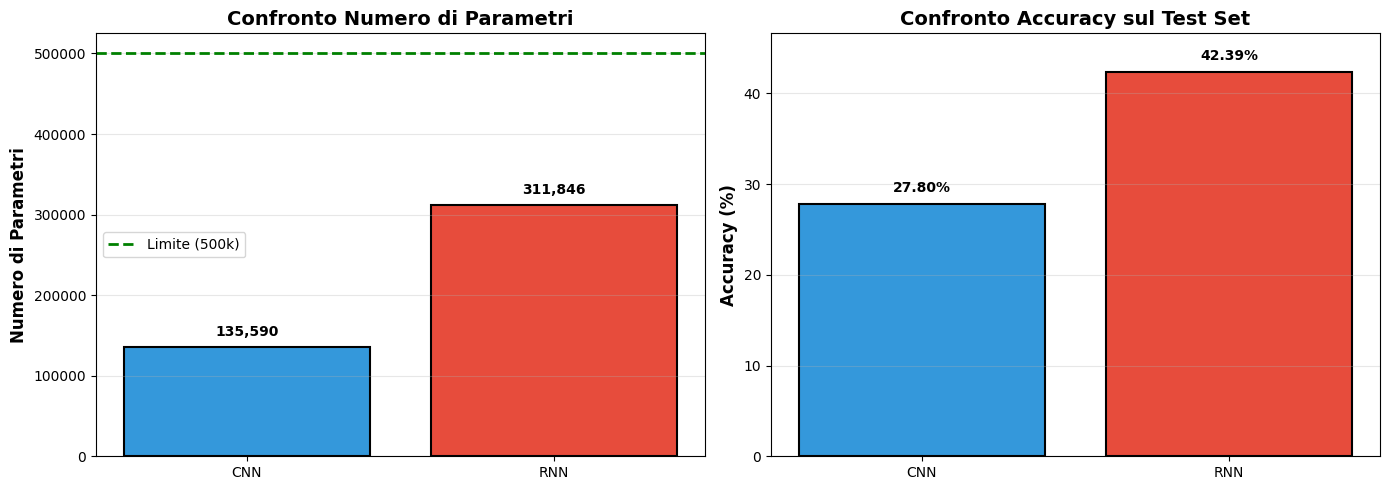

In [33]:
# STEP 8: Visualizzazione grafica dei risultati

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grafico 1: numero di parametri
axes[0].bar(['CNN', 'RNN'], [total_params_cnn, total_params_rnn],
            color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Numero di Parametri', fontsize=12, fontweight='bold')
axes[0].set_title('Confronto Numero di Parametri', fontsize=14, fontweight='bold')
axes[0].axhline(y=500000, color='green', linestyle='--', linewidth=2, label='Limite (500k)')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([total_params_cnn, total_params_rnn]):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# grafico 2: accuracy
axes[1].bar(['CNN', 'RNN'], [cnn_accuracy * 100, rnn_accuracy * 100],
            color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Confronto Accuracy sul Test Set', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, max(cnn_accuracy, rnn_accuracy) * 110])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([cnn_accuracy * 100, rnn_accuracy * 100]):
    axes[1].text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
